In [1]:
import sys, os
from pathlib import Path
import warnings 
warnings.filterwarnings("ignore")

# --- robust project root detection ---
CWD = Path.cwd()
PROJECT_ROOT = next((p for p in [CWD] + list(CWD.parents) if (p / "preprocessing").exists()), None)
if PROJECT_ROOT is None:
    raise RuntimeError("Could not find PROJECT_ROOT (no 'preprocessing/' directory found in parents).")

# Make imports work + ensure relative paths are consistent
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

print("CWD:", CWD)
print("PROJECT_ROOT:", PROJECT_ROOT)

from analysis.cox_regression import compute_hazard_ratios
from analysis import calculate_risk_score_with_best_prs
import pandas as pd
from sklearn.preprocessing import StandardScaler
from analysis.metabolite_level_analysis import (
    prepare_duration,
    create_ages_df,
    create_ages_df_with_df
)

CWD: /home/bioinformatics/Desktop/alzheimer_analysis/notebooks
PROJECT_ROOT: /home/bioinformatics/Desktop/alzheimer_analysis


In [2]:
from analysis.config import make_default_paths
# dataset root
DATA_DIR = PROJECT_ROOT / "ROSMAP-AD"
paths = make_default_paths(DATA_DIR)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
metabolite_levels_file_path = paths.metabolite_levels_file_path
clinical_ages_path = paths.clinical_ages_path

PROJECT_ROOT: /home/bioinformatics/Desktop/alzheimer_analysis
DATA_DIR: /home/bioinformatics/Desktop/alzheimer_analysis/ROSMAP-AD


In [3]:
from pathlib import Path

hazard_ratio_prs_list = {}

import os
import glob

# Path to the main folder
main_folder = 'ROSMAP-AD/Final_Prs_Scores'

# Loop through each subfolder
for subfolder in os.listdir(main_folder):
    subfolder_path = os.path.join(main_folder, subfolder)

    # Check if it's a directory
    if os.path.isdir(subfolder_path):
        prs_id = subfolder
        csv_path = os.path.join(subfolder_path, 'prs_scores.csv')
        prs_scores = pd.read_csv(csv_path)               # Contains individual IDs and scores
        rosmap_clinical = pd.read_csv('ROSMAP-AD/raw/clinical.csv')     # Contains ID, Study, and projid

        # Merge on individual ID
        rosmap_clinical['sample_id'] = rosmap_clinical['Sample ID'].astype(str)
        merged = prs_scores.merge(rosmap_clinical, on='sample_id', how='inner')
        prs_df = merged[['sample_id', 'score']]

        scaler = StandardScaler()
        prs_df.loc[:, "score"] = scaler.fit_transform(prs_df[["score"]])

        ages_prs_ = create_ages_df_with_df(prs_df["sample_id"], clinical_ages_path, metabolite_levels_file_path)
        duration_prs_ = prepare_duration(ages_prs_)
        hr_prs = compute_hazard_ratios(prs_df['score'], duration_prs_)
        hazard_ratio_prs_list[prs_id] = hr_prs

Log(HR) (coef): -0.1267141922749944
Hazard Ratio (exp(coef)): 0.8809854290597149
P-value: 0.6746433944606156
Log(HR) (coef): 0.3061131149542902
Hazard Ratio (exp(coef)): 1.358135923342439
P-value: 0.24905011987760994
Log(HR) (coef): -0.10503392470578503
Hazard Ratio (exp(coef)): 0.9002939798598053
P-value: 0.7182888277208856
Log(HR) (coef): -0.328825559200652
Hazard Ratio (exp(coef)): 0.7197685628000206
P-value: 0.2766222811709308
Log(HR) (coef): 0.15250881940266892
Hazard Ratio (exp(coef)): 1.1647527344726911
P-value: 0.5767162772201626
Log(HR) (coef): 0.35629395975082806
Hazard Ratio (exp(coef)): 1.428027269110508
P-value: 0.1684867307362877
Log(HR) (coef): 0.10060869133568018
Hazard Ratio (exp(coef)): 1.1058438308152265
P-value: 0.7209323360303719
Log(HR) (coef): -0.5402758975475421
Hazard Ratio (exp(coef)): 0.5825874957375258
P-value: 0.08560021438918058
Log(HR) (coef): 0.35677266628645726
Hazard Ratio (exp(coef)): 1.4287110387467272
P-value: 0.19196210439001926
Log(HR) (coef): 0.1

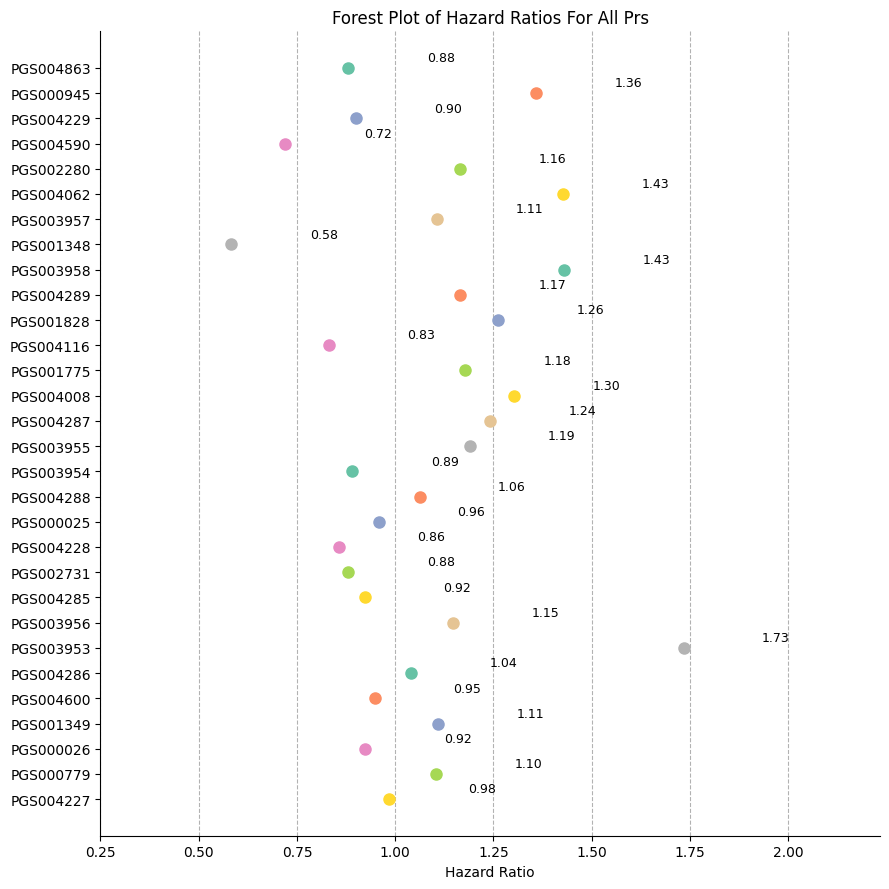

In [4]:
import matplotlib.pyplot as plt
import numpy as np

labels = list(hazard_ratio_prs_list.keys())
odds_ratios = np.array(list(hazard_ratio_prs_list.values()))

fig, ax = plt.subplots(figsize=(9, 9))
fig.patch.set_facecolor('white')  # Set figure background to white
ax.set_facecolor('white')         # Set axes background to white

y_pos = np.arange(len(labels))
colors = plt.cm.Set2.colors  # Light, pastel colors

for i, (odds, label) in enumerate(zip(odds_ratios, labels)):
    ax.plot(odds, y_pos[i], 'o', color=colors[i % len(colors)], markersize=8)
    # Slightly above and right of the point
    ax.text(odds + 0.2, y_pos[i] - 0.15, f"{odds:.2f}",
            va='bottom', ha='left', fontsize=9, color='black')

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, color='black')
ax.invert_yaxis()
ax.set_xlabel("Hazard Ratio", color='black')
ax.set_title("Forest Plot of Hazard Ratios For All Prs", color='black')
ax.set_xlim(0.25, max(odds_ratios) + 0.5)

# Only vertical grid lines
ax.grid(True, axis='x', linestyle='--', alpha=0.6, color='gray')

# Optional: remove top/right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.tick_params(colors='black')

plt.tight_layout()
plt.show()
